> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Time Series Forecasting: Datacenter Power Demand## ARIMA, SARIMA & Seasonal Decomposition**Project:** 009 — The AI Engineering Lab  **Objective:** Forecast hourly datacenter power consumption using classical time series methods.  **Advanced Concepts:** ACF/PACF analysis, ARIMA order selection via AIC, seasonal decomposition, walk-forward validation.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data17,520 hourly readings (~2 years).

In [2]:
df = pd.read_csv('../data/datacenter_power_demand.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (17520, 2)
Columns: ['timestamp', 'power_kw']


,timestamp,power_kw
0,2022-01-01 00:00:00,1059.1
1,2022-01-01 01:00:00,1027.1
2,2022-01-01 02:00:00,1099.0
3,2022-01-01 03:00:00,1131.7
4,2022-01-01 04:00:00,1079.2


In [3]:
# Identify time and value columns
time_col = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower() or 'hour' in c.lower()]
if time_col:
    df[time_col[0]] = pd.to_datetime(df[time_col[0]])
    df = df.set_index(time_col[0])
    df = df.sort_index()

# Use first numeric column as target
value_col = df.select_dtypes(include=[np.number]).columns[0]
ts = df[value_col].dropna()
print(f'Time series: {len(ts)} points, col={value_col}')
print(f'Range: {ts.index[0]} to {ts.index[-1]}')
print(f'Mean: {ts.mean():.1f}, Std: {ts.std():.1f}')

Time series: 17520 points, col=power_kw
Range: 2022-01-01 00:00:00 to 2023-12-31 23:00:00
Mean: 1637.9, Std: 266.9


---## 3. Time Series Visualization

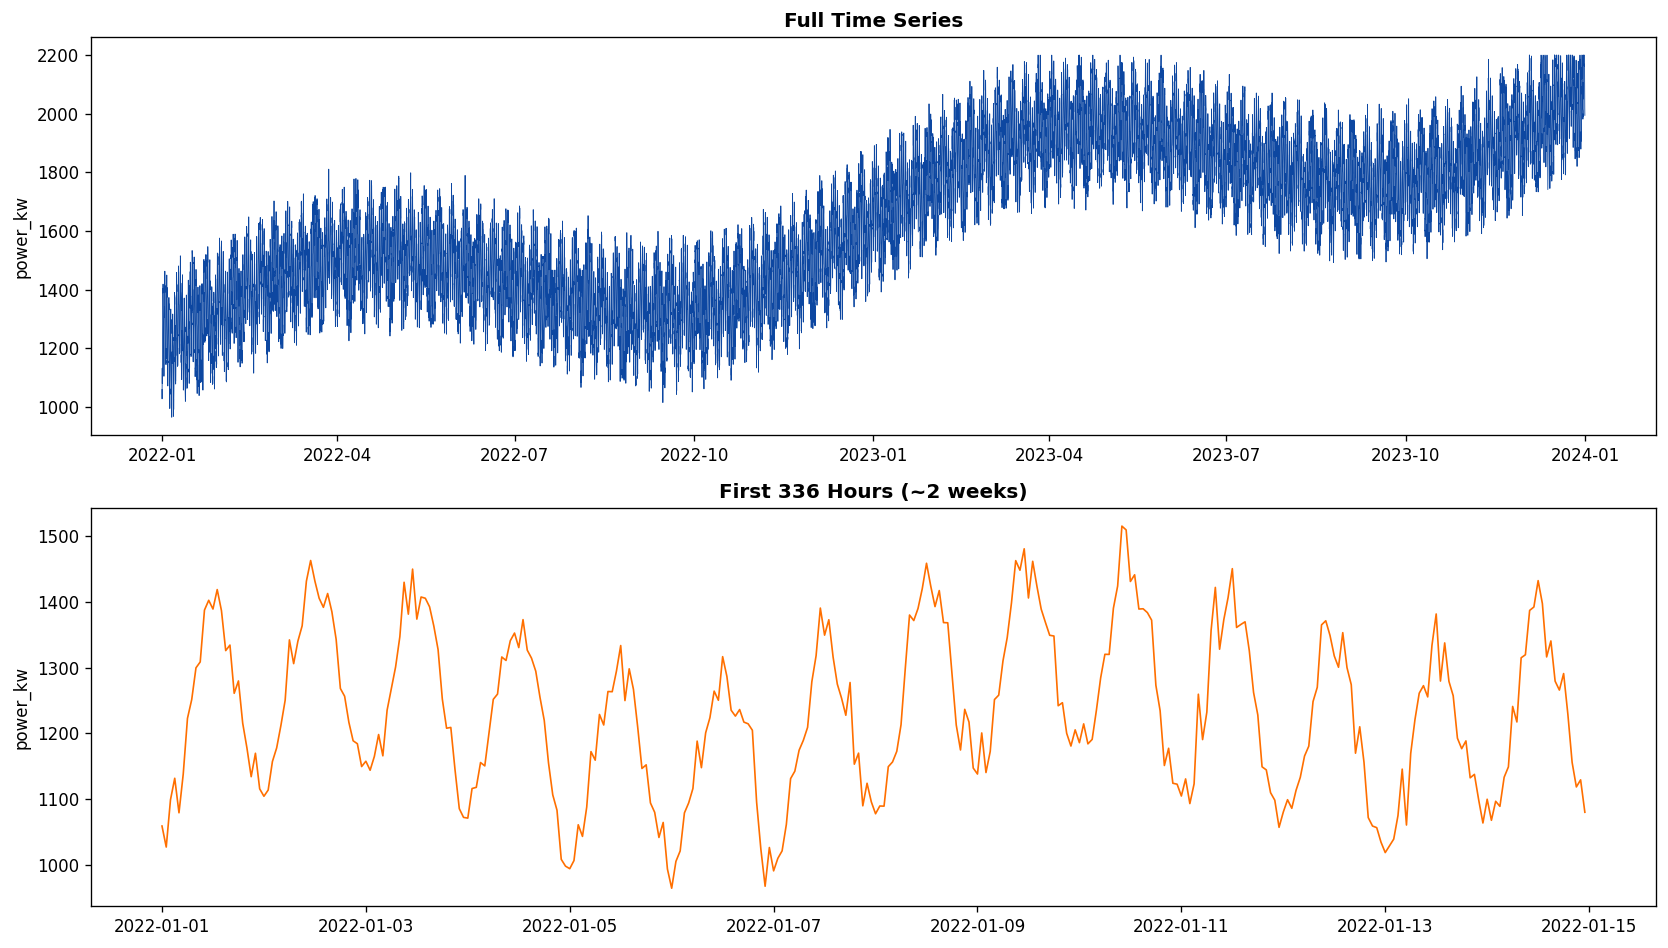

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(ts.index, ts.values, linewidth=0.5, color=COLORS['primary'])
axes[0].set_title('Full Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel(value_col)

# Zoom into 2 weeks
n_zoom = min(336, len(ts))
axes[1].plot(ts.index[:n_zoom], ts.values[:n_zoom], linewidth=1, color=COLORS['secondary'])
axes[1].set_title(f'First {n_zoom} Hours (~2 weeks)', fontsize=12, fontweight='bold')
axes[1].set_ylabel(value_col)
plt.tight_layout()
plt.savefig('../assets/proj1_datacenter_ts_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. Stationarity & ADF Test

ADF Statistic: -7.7647
p-value: 0.000000
Stationary: Yes


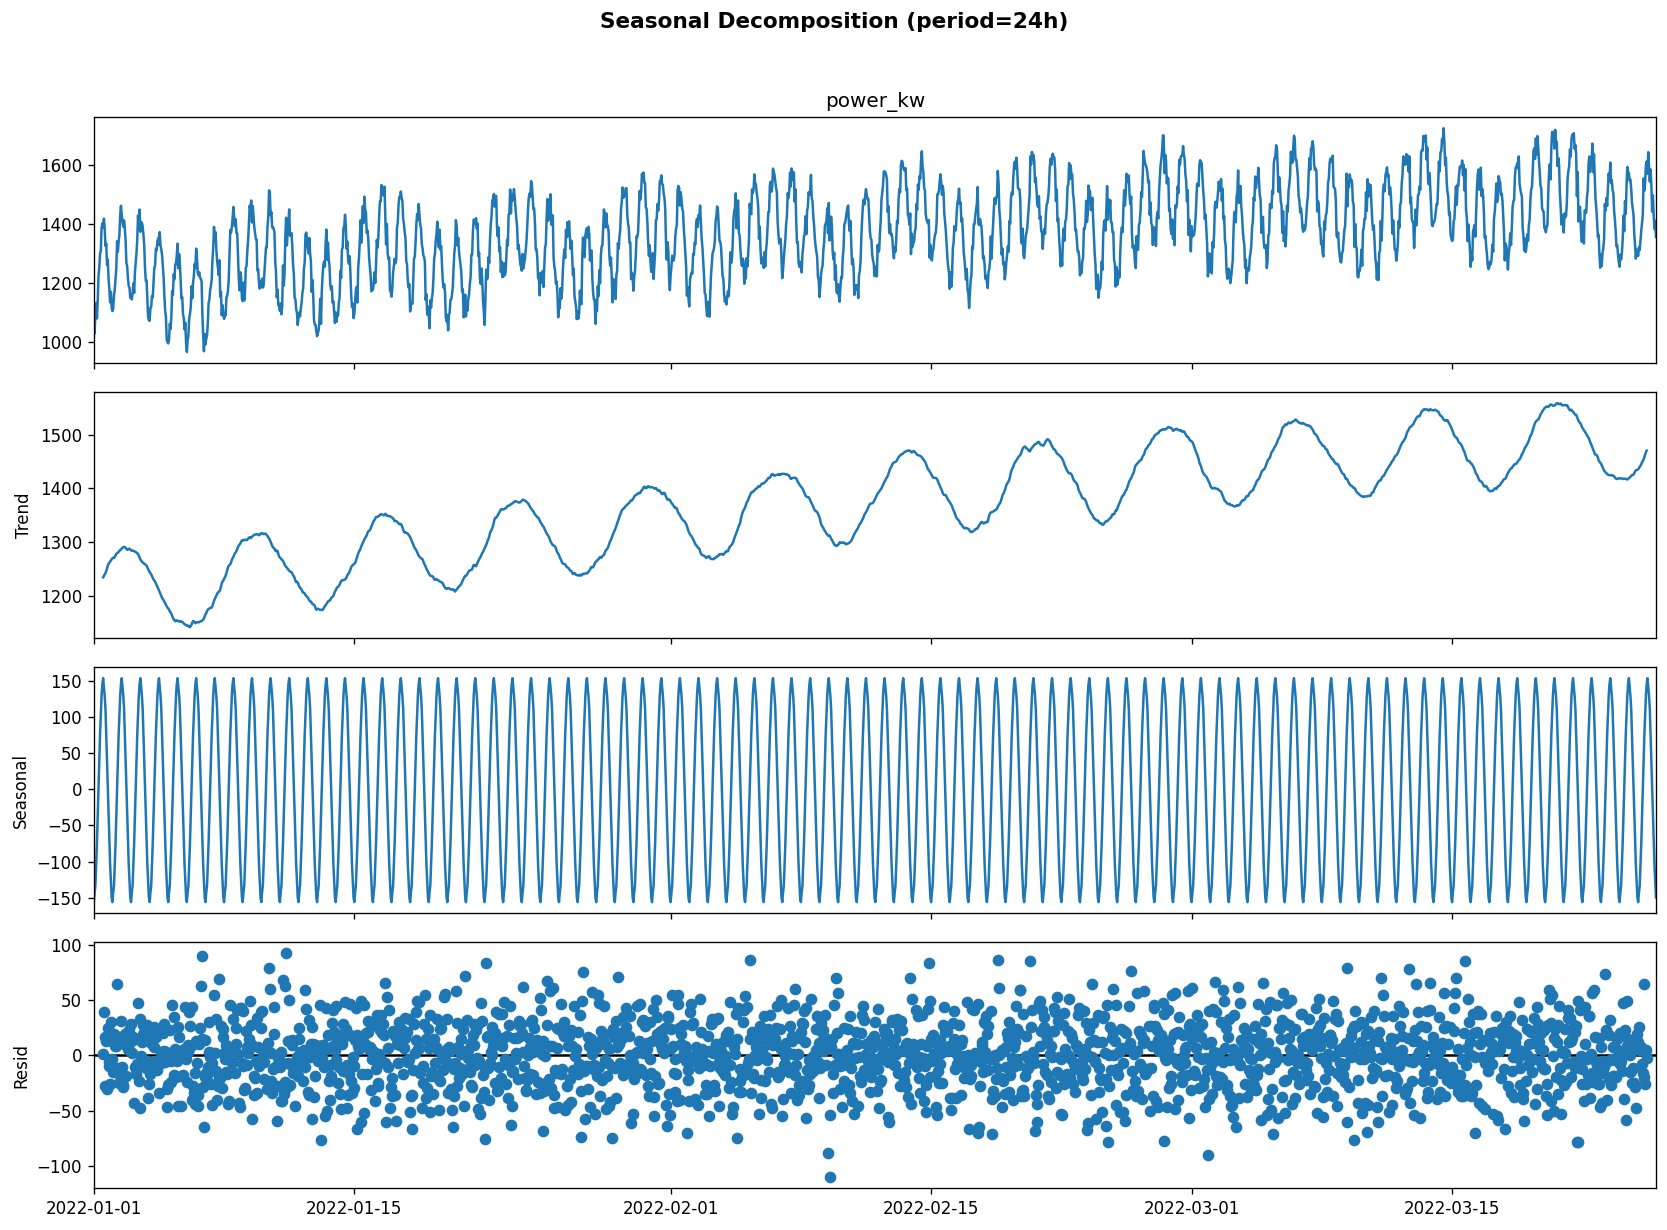

In [5]:
result = adfuller(ts.values[:5000])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.6f}')
print(f'Stationary: {"Yes" if result[1] < 0.05 else "No (needs differencing)"}')

# Seasonal decomposition on subset
subset = ts.iloc[:min(2016, len(ts))]
if len(subset) > 48:
    decomp = seasonal_decompose(subset, model='additive', period=24)
    fig = decomp.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle('Seasonal Decomposition (period=24h)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../assets/proj1_datacenter_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()

---## 5. ACF/PACF Analysis

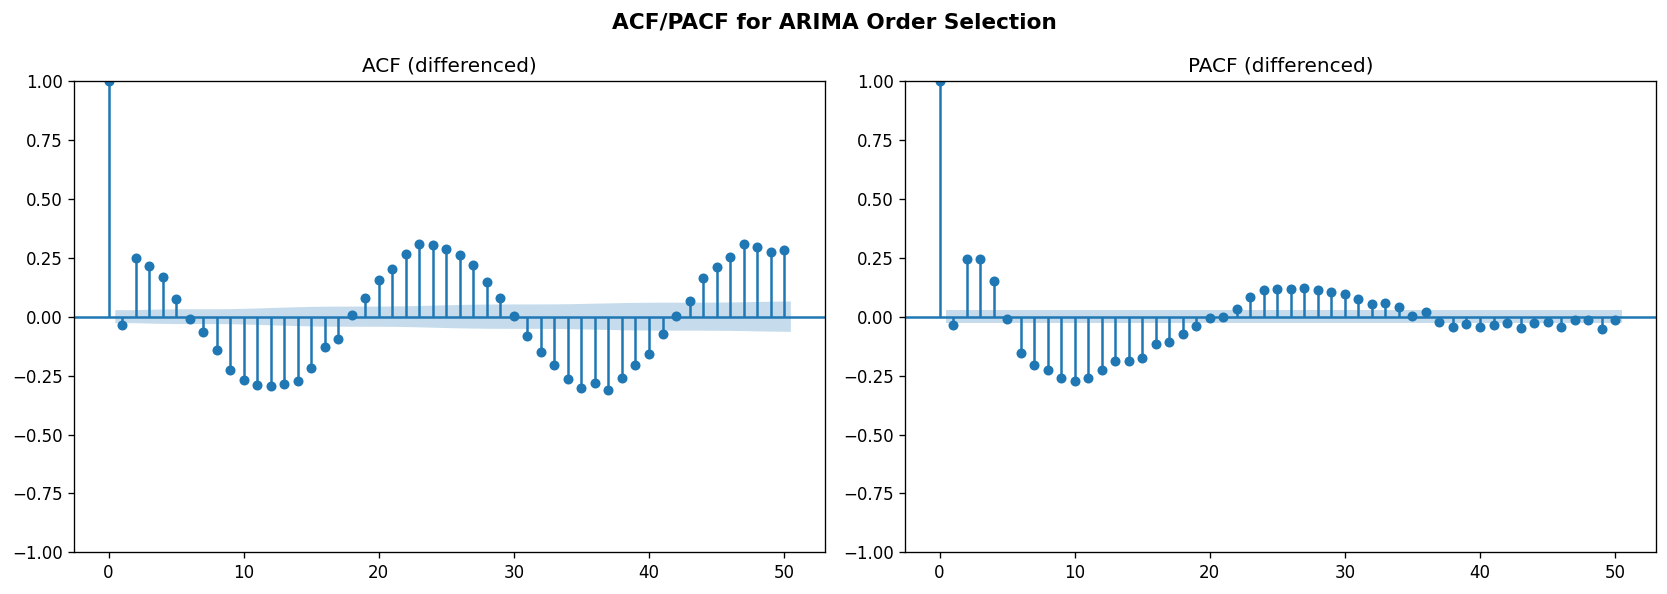

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
subset_diff = ts.diff().dropna().iloc[:5000]
plot_acf(subset_diff, lags=50, ax=axes[0])
axes[0].set_title('ACF (differenced)')
plot_pacf(subset_diff, lags=50, ax=axes[1])
axes[1].set_title('PACF (differenced)')
plt.suptitle('ACF/PACF for ARIMA Order Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_datacenter_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

---## 6. ARIMA Forecast

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA(2,1,2) AIC: 20654.0


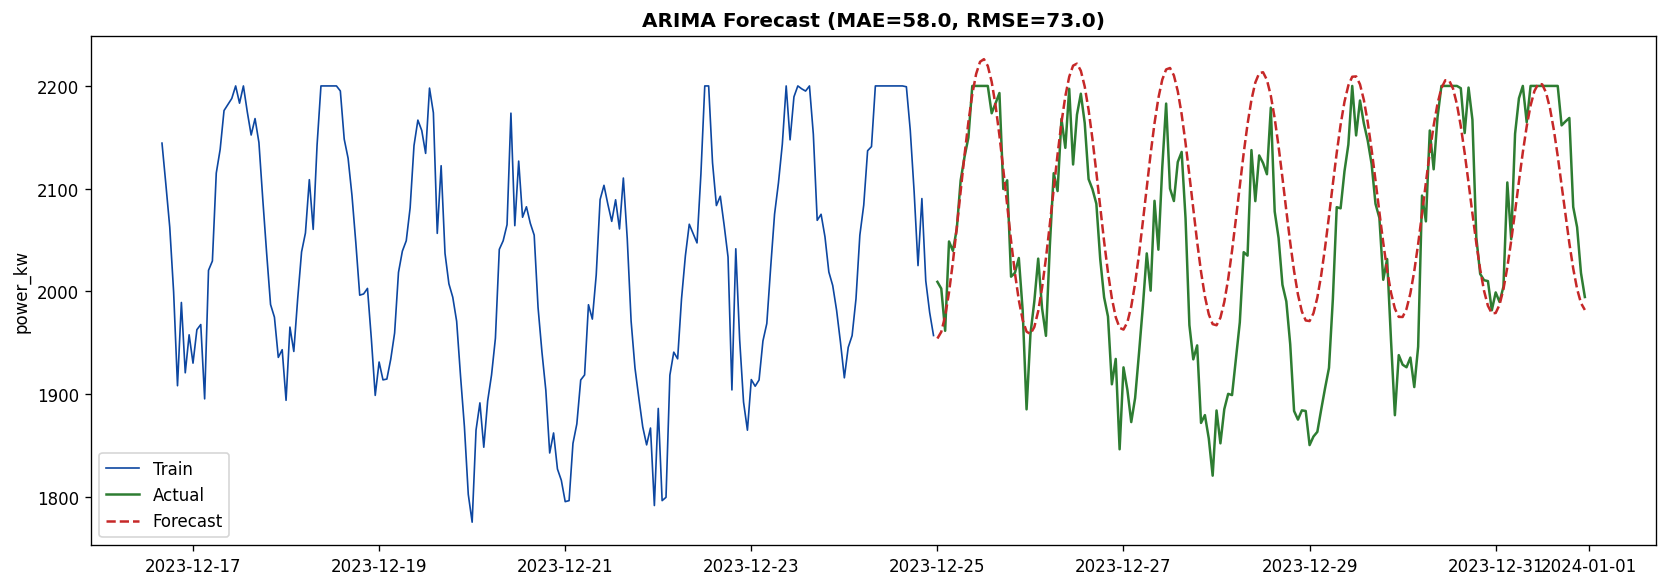

MAE: 57.99, RMSE: 72.97
Notebook complete.


In [7]:
# Use last portion for test
n_test = min(168, len(ts) // 10)
train = ts.iloc[:-n_test]
test = ts.iloc[-n_test:]

# Fit ARIMA on a manageable subset
train_sub = train.iloc[-min(2000, len(train)):]
model = ARIMA(train_sub, order=(2, 1, 2))
fit = model.fit()
print(f'ARIMA(2,1,2) AIC: {fit.aic:.1f}')

forecast = fit.forecast(steps=n_test)
mae = mean_absolute_error(test.values, forecast.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast.values))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-200:], train.values[-200:], color=COLORS['primary'], linewidth=1, label='Train')
ax.plot(test.index, test.values, color=COLORS['accent'], linewidth=1.5, label='Actual')
ax.plot(test.index, forecast.values, color=COLORS['highlight'], linewidth=1.5, linestyle='--', label='Forecast')
ax.set_title(f'ARIMA Forecast (MAE={mae:.1f}, RMSE={rmse:.1f})', fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylabel(value_col)
plt.tight_layout()
plt.savefig('../assets/proj1_datacenter_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}')
print('Notebook complete.')